# Multi-Agent Target Tracking via a Time-Expanded Cellular Sheaf

This version encodes dynamics and coordination directly in one sheaf.
Each vertex is one agent or one target at one time step.

For agents, the stalk is augmented as

$$
z_{i,t} = \begin{bmatrix} x_{i,t} \\ u_{i,t} \end{bmatrix}
\in \mathbb{R}^{n_x+n_u},
\qquad
x_{i,t+1} = A_d x_{i,t} + B_d u_{i,t}.
$$

Edge families:

1. Temporal edges `agent(i,t) ↔ agent(i,t+1)` encode dynamics.
2. Temporal edges `target(j,t) ↔ target(j,t+1)` encode target evolution.
3. In-time edges `agent(i,t) ↔ agent(i',t)` encode consensus (position match).
4. In-time edges `agent(i,t) ↔ target(assign(i),t)` encode tracking/pinning.

Targets are modeled with the same augmented quadrotor stalks as agents so
that the tracking problem is feasible under the same sampled dynamics.

In [1]:
using CellularSheaves
using CellularSheaves.TrajectorySheaves: continuous_to_discrete_zoh
using LinearAlgebra
using BlockArrays
using Plots

## Step 1: Single-agent dynamics (planar quadrotor)

In [2]:
g = 9.81
m_veh = 0.5
I_quad = 0.01
ell = 0.25

Ac = [0.0  0.0   0.0   1.0  0.0  0.0;
      0.0  0.0   0.0   0.0  1.0  0.0;
      0.0  0.0   0.0   0.0  0.0  1.0;
      0.0  0.0  -g     0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0]

Bc = [0.0             0.0;
      0.0             0.0;
      0.0             0.0;
      0.0             0.0;
      1.0 / m_veh     1.0 / m_veh;
      ell / (2I_quad) -ell / (2I_quad)]

h = 0.05
Ad, Bd = continuous_to_discrete_zoh(Ac, Bc, h)

nx = size(Ad, 1)
nu = size(Bd, 2)
npos = 2   # use (y,z) for consensus and pinning

function selector_matrix(state_indices::AbstractVector{<:Integer}, full_dim::Int)
    @assert all(1 .<= state_indices .<= full_dim)
    selector = zeros(Float64, length(state_indices), full_dim)
    for (row, col) in enumerate(state_indices)
        selector[row, col] = 1.0
    end
    return selector
end

selector_matrix (generic function with 1 method)

## Step 2: Time-expanded multi-agent sheaf construction

In [3]:
"""
    build_time_expanded_tracking_sheaf(
        n_agents, n_targets, k, Ad, Bd;
        agent_edges, assignment,
        target_transition, consensus_weight, pinning_weight)

Construct a sheaf whose vertices are `(entity, time)` pairs.

- Agent stalk dimension: `nx + nu` (state + control).
- Target stalk dimension: `nx + nu` (state + control).
"""
function build_time_expanded_tracking_sheaf(
    n_agents::Int,
    n_targets::Int,
    k::Int,
    Ad::AbstractMatrix,
    Bd::AbstractMatrix;
    agent_edges::Vector{Tuple{Int,Int}},
    assignment::Vector{Int},
    agent_consensus_states::AbstractVector{<:Integer},
    target_pinning_states::AbstractVector{<:Integer},
    consensus_weight::Float64=1.0,
    pinning_weight::Float64=5.0,
)
    nx = size(Ad, 1)
    nu = size(Bd, 2)
    nt = nx + nu

    n_per_t = n_agents + n_targets
    n_vertices = (k + 1) * n_per_t

    vertex_dims = fill(nt, n_vertices)

    function vid_agent(i::Int, t::Int)
        return t * n_per_t + i
    end

    function vid_target(j::Int, t::Int)
        return t * n_per_t + n_agents + j
    end

    for t in 0:k
        for i in 1:n_agents
            vertex_dims[vid_agent(i, t)] = nx + nu
        end
    end

    sheaf = EuclideanSheaf{Float64}(vertex_dims)

    agent_now_map = hcat(Matrix(Ad), Matrix(Bd))
    agent_next_map = hcat(Matrix{Float64}(I, nx, nx), zeros(nx, nu))

    for t in 0:k-1
        for i in 1:n_agents
            add_sheaf_edge!(
                sheaf,
                vid_agent(i, t),
                vid_agent(i, t + 1),
                agent_now_map,
                agent_next_map,
            )
        end
    end

    for t in 0:k-1
        for j in 1:n_targets
            add_sheaf_edge!(
                sheaf,
                vid_target(j, t),
                vid_target(j, t + 1),
                agent_now_map,
                agent_next_map,
            )
        end
    end

    agent_selector = selector_matrix(agent_consensus_states, nx)
    target_selector = selector_matrix(target_pinning_states, nt)
    P_agent = hcat(agent_selector, zeros(size(agent_selector, 1), nx - size(agent_selector, 2) + nu))
    P_target = hcat(target_selector, zeros(size(target_selector, 1), nt - size(target_selector, 2)))
    cscale = sqrt(consensus_weight)
    pscale = sqrt(pinning_weight)

    for t in 0:k
        for (i, j) in agent_edges
            add_sheaf_edge!(
                sheaf,
                vid_agent(i, t),
                vid_agent(j, t),
                cscale * P_agent,
                cscale * P_agent,
            )
        end
    end

    for t in 0:k
        for i in 1:n_agents
            j = assignment[i]
            add_sheaf_edge!(
                sheaf,
                vid_agent(i, t),
                vid_target(j, t),
                pscale * P_agent,
                pscale * P_target,
            )
        end
    end

    index = (
        agent=vid_agent,
        target=vid_target,
        n_per_t=n_per_t,
        nx=nx,
        nu=nu,
        nt=nt,
    )

    return sheaf, index
end

Main.var"##386".build_time_expanded_tracking_sheaf

## Step 3: Problem instance

In [4]:
n_agents = 2
n_targets = 2
k = 36

agent_edges = [(1, 2)]
assignment = [1, 2]   # agent i tracks target assignment[i]
    agent_consensus_states = [1, 2]
    target_pinning_states = [1, 2]

sheaf, idx = build_time_expanded_tracking_sheaf(
    n_agents,
    n_targets,
    k,
    Ad,
    Bd;
    agent_edges=agent_edges,
    assignment=assignment,
    agent_consensus_states=agent_consensus_states,
    target_pinning_states=target_pinning_states,
    consensus_weight=1.0,
    pinning_weight=8.0,
)

println("Vertices: ", length(vertex_stalks(sheaf)))
println("Edges:    ", length(edge_stalks(sheaf)))

Vertices: 148
Edges:    255


## Step 4: Boundary data and harmonic extension

We fix initial/final agent states and target endpoints only.

In [5]:
function agent_stalk(x::AbstractVector, u::AbstractVector)
    return vcat(Vector{Float64}(x), Vector{Float64}(u))
end

function generate_quadrotor_reference_trajectory(x0::AbstractVector, xk::AbstractVector)
    reference_sheaf = EuclideanSheaf{Float64}(fill(nx + nu, k + 1))
    reference_now_map = hcat(Matrix(Ad), Matrix(Bd))
    reference_next_map = hcat(Matrix{Float64}(I, nx, nx), zeros(nx, nu))
    for t in 1:k
        add_sheaf_edge!(reference_sheaf, t, t + 1, reference_now_map, reference_next_map)
    end

    reference_boundary = Dict{Int,Vector{Float64}}(
        1 => agent_stalk(x0, zeros(nu)),
        k + 1 => agent_stalk(xk, zeros(nu)),
    )

    reference_path, _ = harmonic_extension(reference_sheaf, reference_boundary)
    return [Array(reference_path[Block(t)]) for t in 1:k+1]
end

boundary = Dict{Int,Vector{Float64}}()

x0_a1 = zeros(nx)
xk_a1 = zeros(nx)
xk_a1[1] = 1.0
xk_a1[2] = 0.5

x0_a2 = copy(x0_a1)
xk_a2 = copy(xk_a1)

u0 = zeros(nu)

boundary[idx.agent(1, 0)] = agent_stalk(x0_a1, u0)
boundary[idx.agent(2, 0)] = agent_stalk(x0_a2, u0)
boundary[idx.agent(1, k)] = agent_stalk(xk_a1, u0)
boundary[idx.agent(2, k)] = agent_stalk(xk_a2, u0)

target0 = [
    zeros(nx),
    zeros(nx),
]
targetk = [
    [1.0, 0.5, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.5, 0.0, 0.0, 0.0, 0.0],
]

target_reference = [
    generate_quadrotor_reference_trajectory(target0[1], targetk[1]),
    generate_quadrotor_reference_trajectory(target0[2], targetk[2]),
]

for j in 1:n_targets
    for t in 0:k
        boundary[idx.target(j, t)] = target_reference[j][t + 1]
    end
end

z_harmonic, null_basis = harmonic_extension(sheaf, boundary)

d = coboundary_map(sheaf)
residual = norm(d * Array(z_harmonic))

println("Harmonic extension residual ||d*z|| = ", residual)
println("Nullspace dimension = ", size(null_basis, 2))

Harmonic extension residual ||d*z|| = 1.948821699790103e-6
Nullspace dimension = 0


## Step 5: Extract trajectories

In [6]:
function unpack_agent_block(v::AbstractVector, nx::Int, nu::Int)
    return v[1:nx], v[nx+1:nx+nu]
end

times = h .* (0:k)

y1 = zeros(k + 1)
z1 = zeros(k + 1)
phi1 = zeros(k + 1)
y2 = zeros(k + 1)
z2 = zeros(k + 1)
phi2 = zeros(k + 1)
u11 = zeros(k + 1)
u12 = zeros(k + 1)
u21 = zeros(k + 1)
u22 = zeros(k + 1)

for t in 0:k
    b1 = Array(z_harmonic[Block(idx.agent(1, t))])
    b2 = Array(z_harmonic[Block(idx.agent(2, t))])
    x1, u1 = unpack_agent_block(b1, nx, nu)
    x2, u2 = unpack_agent_block(b2, nx, nu)

    y1[t + 1] = x1[1]
    z1[t + 1] = x1[2]
    phi1[t + 1] = x1[3]
    y2[t + 1] = x2[1]
    z2[t + 1] = x2[2]
    phi2[t + 1] = x2[3]

    u11[t + 1] = u1[1]
    u12[t + 1] = u1[2]
    u21[t + 1] = u2[1]
    u22[t + 1] = u2[2]
end

## Step 6: Visualize trajectories in a 2x2 multipanel figure

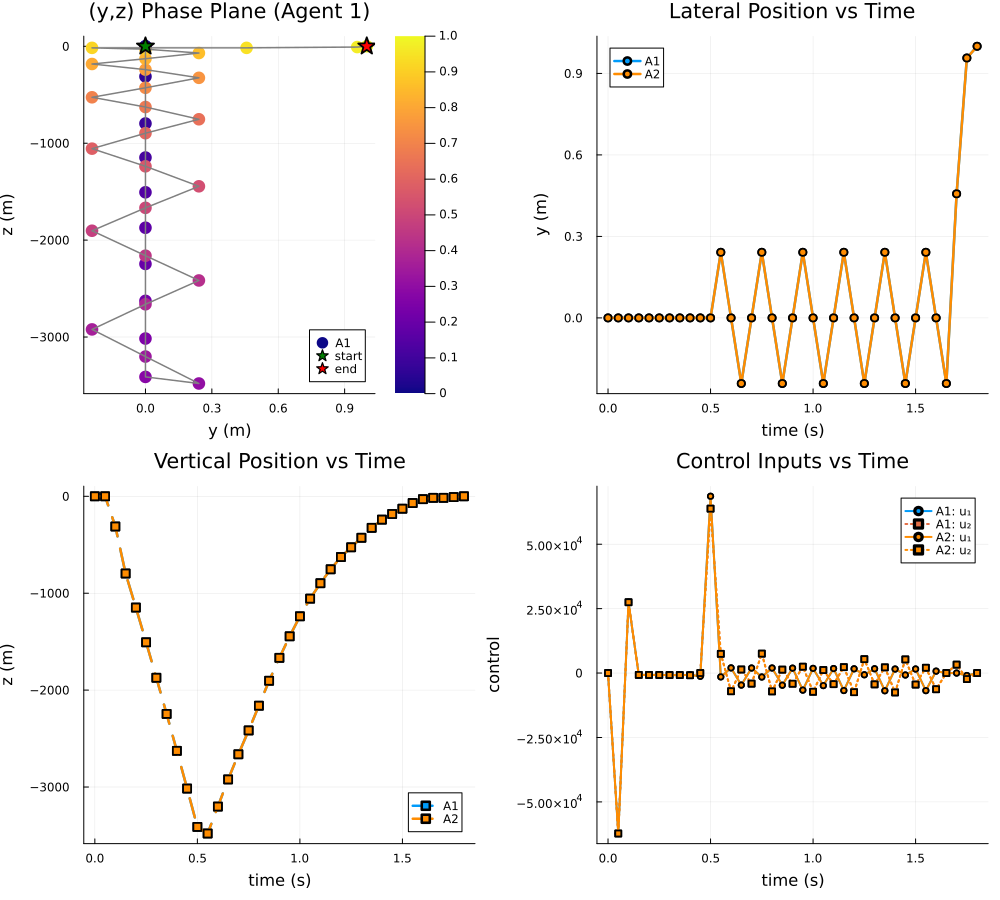

In [7]:
t_normalized = range(0.0, 1.0; length=k+1)

p_plane = scatter(y1, z1;
    marker_z=t_normalized, color=:plasma, colorbar=true,
    label="A1", xlabel="y (m)", ylabel="z (m)",
    title="(y,z) Phase Plane (Agent 1)",
    markerstrokewidth=0, markersize=7)
plot!(p_plane, y1, z1; lw=1.5, color=:gray, label="")
scatter!(p_plane, [y1[1]], [z1[1]]; color=:green, markersize=9, markershape=:star5, label="start")
scatter!(p_plane, [y1[end]], [z1[end]]; color=:red, markersize=9, markershape=:star5, label="end")

p_y = plot(times, y1;
    lw=2.5, marker=:circle, label="A1",
    xlabel="time (s)", ylabel="y (m)",
    title="Lateral Position vs Time",
    markersize=4)
plot!(p_y, times, y2; lw=2.5, marker=:circle, color=:darkorange, label="A2", markersize=4)

p_z = plot(times, z1;
    lw=2.5, marker=:square, label="A1",
    xlabel="time (s)", ylabel="z (m)",
    title="Vertical Position vs Time",
    markersize=4, linestyle=:dash)
plot!(p_z, times, z2; lw=2.5, marker=:square, color=:darkorange, label="A2", markersize=4, linestyle=:dash)

p_ctrl = plot(times, u11;
    lw=2, marker=:circle, label="A1: u₁",
    xlabel="time (s)", ylabel="control",
    title="Control Inputs vs Time",
    markersize=3)
plot!(p_ctrl, times, u12; lw=2, marker=:square, linestyle=:dot, label="A1: u₂", markersize=3)
plot!(p_ctrl, times, u21; lw=2, marker=:circle, color=:darkorange, label="A2: u₁", markersize=3)
plot!(p_ctrl, times, u22; lw=2, marker=:square, color=:darkorange, linestyle=:dot, label="A2: u₂", markersize=3)

plot(p_plane, p_y, p_z, p_ctrl; layout=(2, 2), size=(1000, 900))

## Step 7: Check temporal dynamics edges directly

In [8]:
max_dyn_residual = Ref(0.0)
for t in 0:k-1
    for i in 1:n_agents
        zt = Array(z_harmonic[Block(idx.agent(i, t))])
        zt1 = Array(z_harmonic[Block(idx.agent(i, t + 1))])

        xt, ut = unpack_agent_block(zt, nx, nu)
        xt1, _ = unpack_agent_block(zt1, nx, nu)

        r = norm(Ad * xt + Bd * ut - xt1)
        max_dyn_residual[] = max(max_dyn_residual[], r)
    end
end

println("Max agent dynamics residual = ", max_dyn_residual[])

Max agent dynamics residual = 3.0037587155940507e-7


## Key takeaway

This construction uses one sheaf to encode:
- dynamics (temporal edges),
- agent-agent consensus (in-time edges),
- agent-target tracking (pinning edges).

No direct-sum black-box system is formed; the multi-agent/time structure is
explicit in the sheaf topology.